In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [2]:
len(df)

7043

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
total_charges = pd.to_numeric(df.TotalCharges, errors='coerce')

df[total_charges.isnull()][['customerID', 'TotalCharges']]

,customerID,TotalCharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [7]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')
df.TotalCharges = df.TotalCharges.fillna(0)
df.TotalCharges.value_counts()

TotalCharges
20.20      11
0.00       11
19.75       9
19.65       8
19.90       8
           ..
1990.50     1
7362.90     1
346.45      1
306.60      1
108.15      1
Name: count, Length: 6531, dtype: int64

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

string_columns = df.dtypes[df.dtypes == 'object'].index

for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [9]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [10]:
df.churn = (df.churn == 'yes').astype(int)

In [11]:
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [14]:
df_train_full.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [15]:
df_train, df_val = train_test_split(df_train_full, test_size=0.2, random_state=11)

In [16]:
y_train = df_train.churn.values
y_val = df_val.churn.values

del df_train['churn']
del df_val['churn']

In [17]:
df_train_full.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [18]:
df_train_full.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [19]:
round(df_train_full.churn.value_counts().iloc[1] / (df_train_full.churn.value_counts().iloc[0] + df_train_full.churn.value_counts().iloc[1]), 3)

np.float64(0.27)

In [20]:
global_mean = df_train_full.churn.mean()
round(global_mean, 3)

np.float64(0.27)

In [21]:
categorical = ['gender', 'seniorcitizen', 'partner',
               'dependents', 'phoneservice', 'multiplelines',
               'internetservice', 'onlinesecurity', 'onlinebackup',
               'deviceprotection', 'techsupport', 'streamingtv',
               'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [22]:
df_train_full[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [23]:
female_mean = df_train_full[df_train_full.gender == 'female'].churn.mean()

male_mean = df_train_full[df_train_full.gender == 'male'].churn.mean()

In [24]:
female_mean

np.float64(0.27682403433476394)

In [25]:
male_mean

np.float64(0.2632135306553911)

In [26]:
partner_yes = df_train_full[df_train_full.partner == 'yes'].churn.mean()

partner_no = df_train_full[df_train_full.partner == 'no'].churn.mean()

In [27]:
print(partner_yes)
print(partner_no)

0.20503330866025166
0.3298090040927694


In [28]:
df_group = df_train_full.groupby(by='gender').churn.agg(['mean'])
df_group['diff'] = df_group['mean'] - global_mean
df_group['risk'] = df_group['mean'] / global_mean

In [29]:
from IPython.display import display

for col in categorical: 
    df_group = df_train_full.groupby(by=col).churn.agg(['mean'])
    df_group['diff'] = df_group['mean'] - global_mean
    df_group['risk'] = df_group['mean'] / global_mean
    display(df_group)

,mean,diff,risk
gender,,,
female,0.276824,0.006856,1.025396
male,0.263214,-0.006755,0.974980


,mean,diff,risk
seniorcitizen,,,
0,0.242270,-0.027698,0.897403
1,0.413377,0.143409,1.531208


,mean,diff,risk
partner,,,
no,0.329809,0.059841,1.221659
yes,0.205033,-0.064935,0.759472


,mean,diff,risk
dependents,,,
no,0.313760,0.043792,1.162212
yes,0.165666,-0.104302,0.613651


,mean,diff,risk
phoneservice,,,
no,0.241316,-0.028652,0.893870
yes,0.273049,0.003081,1.011412


,mean,diff,risk
multiplelines,,,
no,0.257407,-0.012561,0.953474
no_phone_service,0.241316,-0.028652,0.893870
yes,0.290742,0.020773,1.076948


,mean,diff,risk
internetservice,,,
dsl,0.192347,-0.077621,0.712482
fiber_optic,0.425171,0.155203,1.574895
no,0.077805,-0.192163,0.288201


,mean,diff,risk
onlinesecurity,,,
no,0.420921,0.150953,1.559152
no_internet_service,0.077805,-0.192163,0.288201
yes,0.153226,-0.116742,0.567570


,mean,diff,risk
onlinebackup,,,
no,0.404323,0.134355,1.497672
no_internet_service,0.077805,-0.192163,0.288201
yes,0.217232,-0.052736,0.804660


,mean,diff,risk
deviceprotection,,,
no,0.395875,0.125907,1.466379
no_internet_service,0.077805,-0.192163,0.288201
yes,0.230412,-0.039556,0.853480


,mean,diff,risk
techsupport,,,
no,0.418914,0.148946,1.551717
no_internet_service,0.077805,-0.192163,0.288201
yes,0.159926,-0.110042,0.592390


,mean,diff,risk
streamingtv,,,
no,0.342832,0.072864,1.269897
no_internet_service,0.077805,-0.192163,0.288201
yes,0.302723,0.032755,1.121328


,mean,diff,risk
streamingmovies,,,
no,0.338906,0.068938,1.255358
no_internet_service,0.077805,-0.192163,0.288201
yes,0.307273,0.037305,1.138182


,mean,diff,risk
contract,,,
month-to-month,0.431701,0.161733,1.599082
one_year,0.120573,-0.149395,0.446621
two_year,0.028274,-0.241694,0.104730


,mean,diff,risk
paperlessbilling,,,
no,0.172071,-0.097897,0.637375
yes,0.338151,0.068183,1.252560


,mean,diff,risk
paymentmethod,,,
bank_transfer_(automatic),0.168171,-0.101797,0.622928
credit_card_(automatic),0.164339,-0.105630,0.608733
electronic_check,0.455890,0.185922,1.688682
mailed_check,0.193870,-0.076098,0.718121


In [30]:
from sklearn.metrics import mutual_info_score

def calculate_mi(series):
    return mutual_info_score(series, df_train_full.churn)

df_mi = df_train_full[categorical].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='MI')

In [31]:
df_mi

,MI
contract,0.098320
onlinesecurity,0.063085
techsupport,0.061032
internetservice,0.055868
onlinebackup,0.046923
deviceprotection,0.043453
paymentmethod,0.043210
streamingtv,0.031853
streamingmovies,0.031581
paperlessbilling,0.017589


In [32]:
df_train_full[numerical].corrwith(df_train_full.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [33]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')

In [34]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)
dv.fit(train_dict)

,dtype,<class 'numpy.float64'>
,separator,'='
,sparse,False
,sort,True


In [35]:
X_train = dv.transform(train_dict)

In [36]:
X_train[0]

array([ 1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  0.  ,
        1.  ,  1.  ,  0.  ,  0.  , 44.65,  0.  ,  1.  ,  0.  ,  0.  ,
        0.  ,  1.  ,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ,  1.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  1.  ,  1.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        1.  ,  1.  ,  0.  ,  0.  ,  0.  ,  0.  ,  1.  ,  1.  , 44.65])

In [37]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=1)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [39]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [40]:
y_pred = model.predict_proba(X_val)[:, 1]

In [41]:
y_pred

array([0.22620376, 0.22676653, 0.2728746 , ..., 0.00750267, 0.06288379,
       0.00430219], shape=(1127,))

In [42]:
y_pred >= 0.5

array([False, False, False, ..., False, False, False], shape=(1127,))

In [43]:
churn = y_pred >= 0.5

In [44]:
(y_val == churn).mean()

np.float64(0.7923691215616682)

In [45]:
model.intercept_[0]

np.float64(-0.12335250609734504)

In [46]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.556),
 'contract=one_year': np.float64(-0.184),
 'contract=two_year': np.float64(-0.496),
 'dependents=no': np.float64(-0.009),
 'dependents=yes': np.float64(-0.114),
 'deviceprotection=no': np.float64(0.061),
 'deviceprotection=no_internet_service': np.float64(-0.106),
 'deviceprotection=yes': np.float64(-0.078),
 'gender=female': np.float64(-0.043),
 'gender=male': np.float64(-0.081),
 'internetservice=dsl': np.float64(-0.353),
 'internetservice=fiber_optic': np.float64(0.336),
 'internetservice=no': np.float64(-0.106),
 'monthlycharges': np.float64(0.001),
 'multiplelines=no': np.float64(-0.17),
 'multiplelines=no_phone_service': np.float64(0.12),
 'multiplelines=yes': np.float64(-0.074),
 'onlinebackup=no': np.float64(0.111),
 'onlinebackup=no_internet_service': np.float64(-0.106),
 'onlinebackup=yes': np.float64(-0.128),
 'onlinesecurity=no': np.float64(0.261),
 'onlinesecurity=no_internet_service': np.float64(-0.106),
 'onlinesecurity=yes'

In [47]:
small_subset = ['contract', 'tenure', 'totalcharges']
train_dict_small = df_train[small_subset].to_dict(orient='records')
dv_small = DictVectorizer(sparse=False)
dv_small.fit(train_dict_small)

X_small_train = dv_small.transform(train_dict_small)

In [48]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'tenure', 'totalcharges'], dtype=object)

In [49]:
model_small = LogisticRegression(solver='liblinear', random_state=1)
model_small.fit(X_small_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [50]:
model_small.intercept_[0]

np.float64(-0.6567147871221283)

In [51]:
dict(zip(dv_small.get_feature_names_out(), model_small.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.912),
 'contract=one_year': np.float64(-0.319),
 'contract=two_year': np.float64(-1.25),
 'tenure': np.float64(-0.095),
 'totalcharges': np.float64(0.001)}

In [52]:
customer = {
'customerid': '8879-zkjof',
'gender': 'female',
'seniorcitizen': 0,
'partner': 'no',
'dependents': 'no',
'tenure': 41,
'phoneservice': 'yes',
'multiplelines': 'no',
'internetservice': 'dsl',
'onlinesecurity': 'yes',
'onlinebackup': 'no',
'deviceprotection': 'yes',
'techsupport': 'yes',
'streamingtv': 'yes',
'streamingmovies': 'yes',
'contract': 'one_year',
'paperlessbilling': 'yes',
'paymentmethod': 'bank_transfer_(automatic)',
'monthlycharges': 79.85,
'totalcharges': 3320.75,
}

In [53]:
X_test = dv.transform([customer])

In [54]:
model.predict_proba(X_test)[:, 1]

array([0.05339718])

In [55]:
customer2 = {
'gender': 'female',
'seniorcitizen': 1,
'partner': 'no',
'dependents': 'no',
'phoneservice': 'yes',
'multiplelines': 'yes',
'internetservice': 'fiber_optic',
'onlinesecurity': 'no',
'onlinebackup': 'no',
'deviceprotection': 'no',
'techsupport': 'no',
'streamingtv': 'yes',
'streamingmovies': 'no',
'contract': 'month-to-month',
'paperlessbilling': 'yes',
'paymentmethod': 'electronic_check',
'tenure': 1,
'monthlycharges': 85.7,
'totalcharges': 85.7
}

In [56]:
X_test2 = dv.transform([customer2])

In [57]:
model.predict_proba(X_test2)[0, 1]

np.float64(0.8286986172749177)

In [58]:
from sklearn.metrics import accuracy_score

thresholds = np.linspace(0, 1, 11)

for t in thresholds:
    churn = y_pred >= t
    acc = accuracy_score(y_val, churn)
    print('%0.2f %0.3f' % (t, acc))

0.00 0.264
0.10 0.588
0.20 0.677
0.30 0.744
0.40 0.770
0.50 0.792
0.60 0.787
0.70 0.774
0.80 0.744
0.90 0.736
1.00 0.736


In [59]:
thresholds = np.linspace(0, 1, 21)
accuracies = []
for t in thresholds:
    acc = accuracy_score(y_val, y_pred >= t)
    accuracies.append(acc)

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

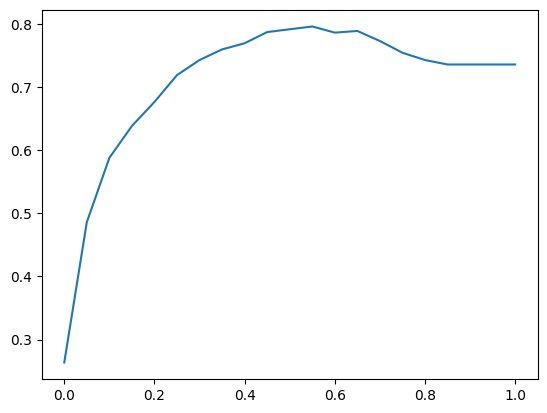

In [60]:
plt.plot(thresholds, accuracies)

plt.legend

In [61]:
val_dict_small = df_val[small_subset].to_dict(orient='records')

X_small_val = dv_small.transform(val_dict_small)
y_pred_small = model_small.predict_proba(X_small_val)[:, 1]

churn_small = y_pred_small >= 0.5
accuracy_score(y_val, churn_small)

0.769299023957409

In [62]:
size_val = len(y_val)
baseline = np.repeat(False, size_val)

In [63]:
accuracy_score(baseline, y_val)

0.7364685004436557

In [64]:
t = 0.5
predict_churn = (y_pred >= t)
predict_no_churn = (y_pred < t)

actual_churn = (y_val == 1)
actual_no_churn = (y_val == 0)

true_positive = (predict_churn & actual_churn).sum()
false_positive = (predict_churn & actual_no_churn).sum()

false_negative = (predict_no_churn & actual_churn).sum()
true_negative = (predict_no_churn & actual_no_churn).sum()

In [65]:
confusion_table = np.array(
    [[true_negative, false_positive], 
    [false_negative, true_positive]]
)

In [66]:
confusion_table

array([[726, 104],
       [130, 167]])

In [67]:
confusion_table / confusion_table.sum()

array([[0.64418811, 0.09228039],
       [0.11535049, 0.14818101]])

In [68]:
P = true_positive / (true_positive + false_positive) # точность

In [69]:
P

np.float64(0.6162361623616236)

In [70]:
R = true_positive / (true_positive + false_negative) # отклик

In [71]:
R

np.float64(0.5622895622895623)

In [72]:
FPR = false_positive / (false_positive + true_negative)

In [73]:
TPR = true_positive / (true_positive + false_negative)

In [74]:
FPR

np.float64(0.12530120481927712)

In [75]:
TPR

np.float64(0.5622895622895623)

In [76]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    tp = ((y_pred >= t) & (y_val == 1)).sum()
    fp = ((y_pred >= t) & (y_val == 0)).sum()
    fn = ((y_pred < t) & (y_val == 1)).sum()
    tn = ((y_pred < t) & (y_val == 0)).sum()
    scores.append((t, tp, fp, fn, tn))

In [77]:
df_scores = pd.DataFrame(scores)

df_scores.columns = ['threshold', 'tp', 'fp', 'fn', 'tn']

In [78]:
df_scores[::10]

,threshold,tp,fp,fn,tn
0,0.0,297,830,0,0
10,0.1,275,442,22,388
20,0.2,253,320,44,510
30,0.3,226,218,71,612
40,0.4,200,162,97,668
50,0.5,167,104,130,726
60,0.6,120,63,177,767
70,0.7,66,24,231,806
80,0.8,9,1,288,829
90,0.9,0,0,297,830


In [79]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [80]:
df_scores[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,297,830,0,0,1.000000,1.000000
10,0.1,275,442,22,388,0.925926,0.532530
20,0.2,253,320,44,510,0.851852,0.385542
30,0.3,226,218,71,612,0.760943,0.262651
40,0.4,200,162,97,668,0.673401,0.195181
50,0.5,167,104,130,726,0.562290,0.125301
60,0.6,120,63,177,767,0.404040,0.075904
70,0.7,66,24,231,806,0.222222,0.028916
80,0.8,9,1,288,829,0.030303,0.001205
90,0.9,0,0,297,830,0.000000,0.000000


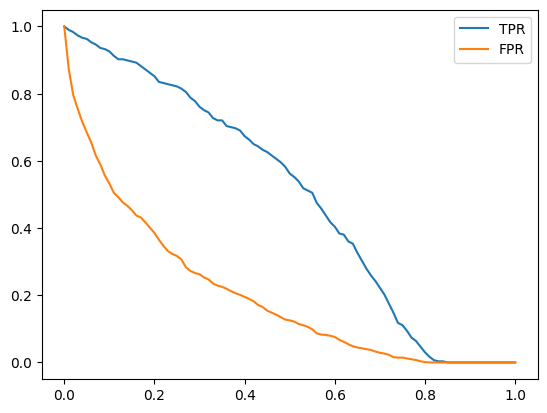

In [81]:
plt.plot(df_scores.threshold, df_scores.tpr, label='TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label='FPR')
plt.legend()

In [82]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        tp = ((y_pred >= t) & (y_val == 1)).sum()
        fp = ((y_pred >= t) & (y_val == 0)).sum()
        fn = ((y_pred < t) & (y_val == 1)).sum()
        tn = ((y_pred < t) & (y_val == 0)).sum()
        scores.append((t, tp, fp, fn, tn))
        
    df_scores = pd.DataFrame(scores)
    df_scores.columns = ['threshold', 'tp', 'fp', 'fn', 'tn']

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [83]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))
df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,297,830,0,0,1.000000,1.000000
10,0.1,268,745,29,85,0.902357,0.897590
20,0.2,235,662,62,168,0.791246,0.797590
30,0.3,200,591,97,239,0.673401,0.712048
40,0.4,167,523,130,307,0.562290,0.630120
50,0.5,138,436,159,394,0.464646,0.525301
60,0.6,105,348,192,482,0.353535,0.419277
70,0.7,83,254,214,576,0.279461,0.306024
80,0.8,49,177,248,653,0.164983,0.213253
90,0.9,31,81,266,749,0.104377,0.097590


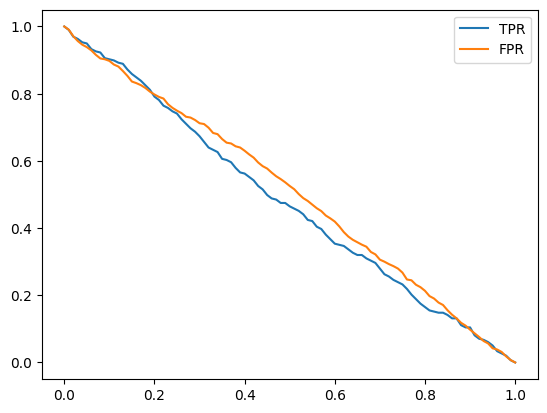

In [84]:
plt.plot(df_rand.threshold, df_rand.tpr, label='TPR')
plt.plot(df_rand.threshold, df_rand.fpr, label='FPR')
plt.legend()

In [85]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()

y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_pred_ideal = np.linspace(0, 1, num_neg + num_pos)

df_ideal = tpr_fpr_dataframe(y_ideal, y_pred_ideal)

In [86]:
df_ideal[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,297,830,0,0,1.000000,1.000000
10,0.1,297,717,0,113,1.000000,0.863855
20,0.2,297,604,0,226,1.000000,0.727711
30,0.3,297,492,0,338,1.000000,0.592771
40,0.4,297,379,0,451,1.000000,0.456627
50,0.5,297,267,0,563,1.000000,0.321687
60,0.6,297,154,0,676,1.000000,0.185542
70,0.7,297,41,0,789,1.000000,0.049398
80,0.8,226,0,71,830,0.760943,0.000000
90,0.9,113,0,184,830,0.380471,0.000000


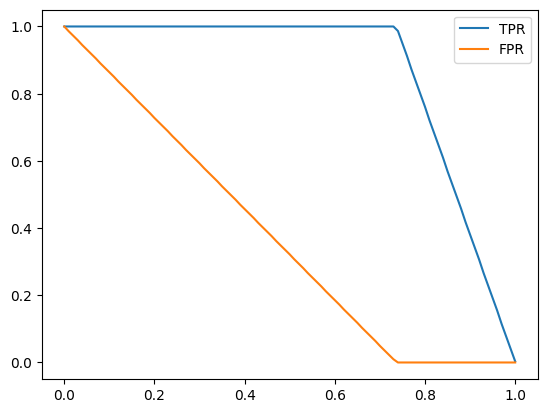

In [87]:
plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR')
plt.legend()

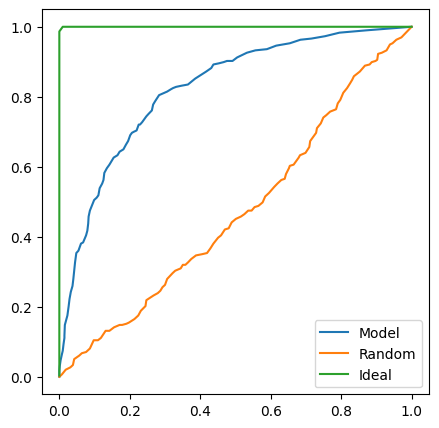

In [88]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
plt.plot(df_rand.fpr, df_rand.tpr, label='Random')
plt.plot(df_ideal.fpr, df_ideal.tpr, label='Ideal')

plt.legend()

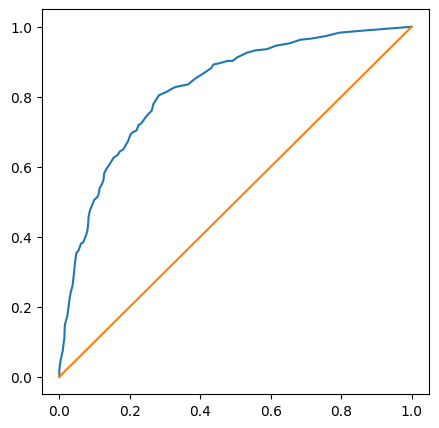

In [89]:
plt.figure(figsize=(5, 5))
plt.plot(df_scores.fpr, df_scores.tpr)
plt.plot([0, 1], [0, 1])

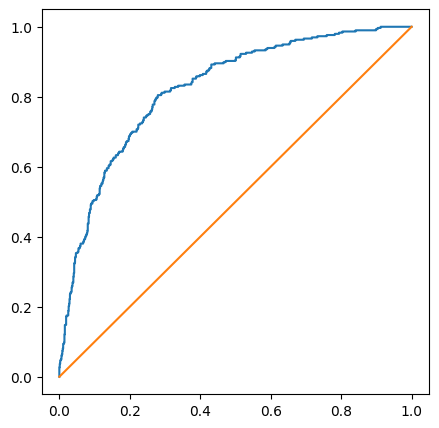

In [90]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_pred)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])

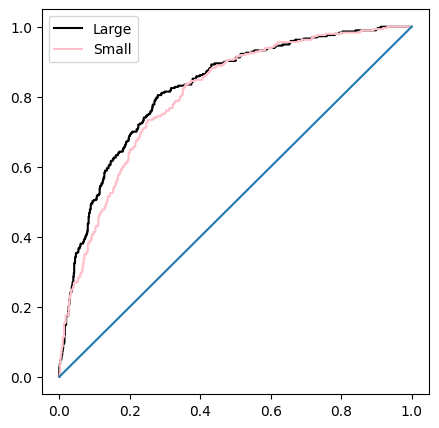

In [91]:
fpr_large, tpr_large, _ = roc_curve(y_val, y_pred)
fpr_small, tpr_small, _ = roc_curve(y_val, y_pred_small)

plt.figure(figsize=(5, 5))

plt.plot(fpr_large, tpr_large, color='black', label='Large')
plt.plot(fpr_small, tpr_small, color='pink', label='Small')
plt.plot([0, 1], [0, 1])
plt.legend()

In [92]:
from sklearn.metrics import auc

auc(df_scores.fpr, df_scores.tpr)

0.8225041580463266

In [93]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_val, y_pred)

0.8227272727272728

In [94]:
roc_auc_score(y_val, y_pred_small)

0.8041195083363758

In [95]:
def train(df, y):
    cat = df[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    dv.fit(cat)

    X = dv.transform(cat)

    model = LogisticRegression(solver='liblinear')
    model.fit(X, y)

    return dv, model


In [96]:
def predict(df, dv, model):
    cat = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(cat)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred
    

In [97]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=10)
aucs = []
for train_idx, val_idx in kfold.split(df_train_full):
    df_train = df_train_full.iloc[train_idx]
    df_val = df_train_full.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    aucs.append(auc)

In [98]:
aucs

[0.8258860020883239,
 0.8257139650113048,
 0.8390884875259874,
 0.8444362835108337,
 0.8415520909408439,
 0.8475597092419522,
 0.8493435635123615,
 0.8363238738118198,
 0.8309402612370341,
 0.8723095345008232]

In [99]:
print(np.mean(aucs), np.std(aucs))

0.8413153771381283 0.013011011444381337


In [100]:
def train(df, y, C):
    cat = df[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    dv.fit(cat)

    X = dv.transform(cat)

    model = LogisticRegression(solver='liblinear', C=C)
    model.fit(X, y)

    return dv, model

In [101]:
nfolds = 5
kfold = KFold(n_splits = nfolds, shuffle=True, random_state=1)

for C in [0.001, 0.01, 0.1, 0.5, 1, 10]:
    aucs = []
    for train_idx, val_idx in kfold.split(df_train_full):
        df_train = df_train_full.iloc[train_idx]
        df_val = df_train_full.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        aucs.append(auc)
    print(C, np.mean(aucs), np.std(aucs))

0.001 0.8250174200538158 0.013055244878120873
0.01 0.8393374164077351 0.00878094783419177
0.1 0.8407595713038944 0.007480059254409878
0.5 0.84117792357321 0.007396479568428505
1 0.841138986248312 0.0074294393591401095
10 0.8411507678154283 0.0073823467033307


In [102]:
y_train = df_train_full.churn.values
y_test = df_test.churn.values

dv, model = train(df_train_full, y_train, C=0.5)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
print('auc = %.3f' % auc)

auc = 0.858


In [103]:
customer = {
'customerid': '8879-zkjof',
'gender': 'female',
'seniorcitizen': 0,
'partner': 'no',
'dependents': 'no',
'tenure': 41,
'phoneservice': 'yes',
'multiplelines': 'no',
'internetservice': 'dsl',
'onlinesecurity': 'yes',
'onlinebackup': 'no',
'deviceprotection': 'yes',
'techsupport': 'yes',
'streamingtv': 'yes',
'streamingmovies': 'yes',
'contract': 'one_year',
'paperlessbilling': 'yes',
'paymentmethod': 'bank_transfer_(automatic)',
'monthlycharges': 79.85,
'totalcharges': 3320.75,
}

In [105]:
df = pd.DataFrame([customer])
y_pred = predict(df, dv, model)
y_pred[0]

np.float64(0.05960552403272276)

In [106]:
def predict_single(customer, dv, model):
    X = dv.transform([customer])
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred[0]
    

In [107]:
predict_single(customer, dv, model)

np.float64(0.05960552403272276)

In [109]:
import pickle

with open('churn-model.bin', 'wb') as f_out:
    pickle.dump((dv, model), f_out)

In [110]:
with open('churn-model.bin', 'rb') as f_in:
    dv, model = pickle.load(f_in)
